# Figure 7E — Classified extracted behaviours (B-SOiD 3D UMAP)

3D UMAP embedding of the B-SOiD behaviour-space, coloured by the
14 unsupervised behaviour clusters. **Clusters 1 and 8** are the two
behaviours that drive the social-behaviour findings in Figures 8 D / E.

**Data.** Per-frame features and B-SOiD cluster assignments from the
three-chamber SIT recordings used for Figures 8 D / E (n = 26 recordings,
58,474 sampled frames at the B-SOiD sample rate). UMAP coordinates are
pre-computed and cached in `data/fig7E_umap3d.csv`.

**Pipeline (matches the canonical B-SOiD recipe).** Pose-tracked
frames → 144-dim spatiotemporal feature set → standard-scaling → UMAP
to 3D → HDBSCAN clustering. UMAP parameters come **verbatim** from
[`YttriLab/B-SOID :: bsoid_umap/train.py`](https://github.com/YttriLab/B-SOID/blob/master/bsoid_umap/train.py)
with the defaults from
[`bsoid_umap/config/GLOBAL_CONFIG.py`](https://github.com/YttriLab/B-SOID/blob/master/bsoid_umap/config/GLOBAL_CONFIG.py):

```python
trained_umap = umap.UMAP(
    n_neighbors  = int(round(np.sqrt(N_frames))),   # = 242 for 58,474 frames
    n_components = 3,
    min_dist     = 0.0,
    random_state = 23,
).fit(StandardScaler().fit_transform(features_144d))
```

The `n_neighbors ≈ √N` setting is what gives the published Fig 7E its
**separated cluster-island look** — smaller `n_neighbors` values
collapse the 14 clusters into a single connected manifold. Cluster
identities are taken from HDBSCAN on B-SOiD's 14-dim sampled embedding
(`min_samples = 200`, `min_cluster_size = 400`,
`cluster_selection_method = "leaf"`, `prediction_data = True`); the same
canonical clusters drive Fig 7 F/G. Noise points are soft-reassigned via
`all_points_membership_vectors` so every frame has a label.

¹ Hsu A.I. & Yttri E.A. (2021). *B-SOiD, an open-source unsupervised
algorithm for identification and fast prediction of behaviors.*
*Nature Communications* **12**, 5188.
doi: [10.1038/s41467-021-25420-x](https://doi.org/10.1038/s41467-021-25420-x).
Code: <https://github.com/YttriLab/B-SOID>.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from matplotlib.transforms import Affine2D
from mpl_toolkits.mplot3d import Axes3D    # noqa: F401 (enables 3D projection)

plt.rcParams["font.family"] = "Arial"

df = pd.read_csv("data/fig7E_umap3d.csv")
print(f"Loaded {len(df):,} frames across {df['cluster'].nunique()} clusters.")
print(df.groupby("cluster").size().rename("n").to_frame().T)


Loaded 58,474 frames across 14 clusters.
cluster   0     1     2     3     4     5     6     7     8     9     10  \
n        926  1031  2658  6235  2783  4727  2484  6914  5206  4759  1649   

cluster    11    12    13  
n        6744  6165  6193  


## Fig 7E (i) — 3D scatter with cluster-number labels

Same B-SOiD-style 3D scatter as the published Fig 7E, with each cluster's
number stamped at its centroid. This makes the link to the **Fig 7F
heatmap** immediate — when 8D singles out a row (e.g. cluster 8 in
LPS-Hx), you can find that cluster's position in behaviour-space at a
glance.


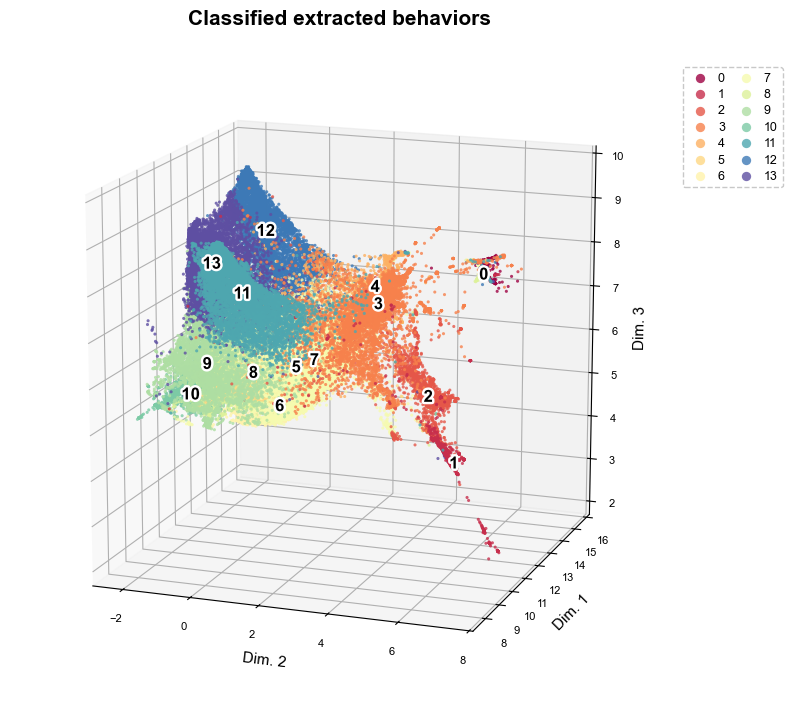

In [2]:
# Reproduces B-SOiD's plot_classes() palette / rendering — published-style:
# uniform alpha across all 14 clusters, cube aspect, only clusters 1 and 8
# labelled at their centroids.
#
# Reference:
#   YttriLab/B-SOID — bsoid_app/bsoid_utilities/visuals.py :: plot_classes()
#       cmap = plt.cm.get_cmap("Spectral")(np.linspace(0, 1, n_clusters))
#       ax.scatter(..., c=cmap[g], s=0.4, marker='o', alpha=0.8)
#       plt.legend(ncol=3, markerscale=6)
import matplotlib as mpl
from matplotlib.patheffects import withStroke

n_clusters = int(df["cluster"].nunique())
R          = np.linspace(0, 1, n_clusters)
PALETTE    = mpl.colormaps["Spectral"](R)        # (n_clusters, 4) RGBA rows

HIGHLIGHT = (1, 8)   # clusters 1 + 8 drive the Fig 7 F/G findings

# ---- Axis-permutation choice ----
# Render Dim 2 on x, Dim 1 on y, Dim 3 on z -- surfaces Cluster 1 as its
# own visible island instead of leaving it buried inside the central sheet.
df = df.rename(columns={'x': '_d1', 'y': '_d2', 'z': '_d3'})
df['x'] = df['_d2']
df['y'] = df['_d1']
df['z'] = df['_d3']
X_LABEL, Y_LABEL, Z_LABEL = 'Dim. 2', 'Dim. 1', 'Dim. 3'

# Tight axis limits around the cluster cores.
def core_range(s, pad=0.08, q=0.005):
    lo, hi = s.quantile(q), s.quantile(1 - q)
    r = hi - lo
    return lo - pad * r, hi + pad * r

xlim = core_range(df["x"]); ylim = core_range(df["y"]); zlim = core_range(df["z"])

fig = plt.figure(figsize=(8.5, 7.5), facecolor="white")
ax  = fig.add_subplot(111, projection="3d", facecolor="white")

# ---- Single uniform scatter pass — published Fig 7E style ----
# All 14 clusters render at the same alpha and point size; the only visual
# emphasis on 1 / 8 comes from their boxed centroid labels.
# Plot largest clusters first so smaller distinctive ones land on top.
sizes      = df["cluster"].value_counts()
plot_order = list(sizes.sort_values(ascending=False).index)
for c in plot_order:
    pts  = df[df["cluster"] == c]
    keep = (pts["x"].between(*xlim) &
            pts["y"].between(*ylim) &
            pts["z"].between(*zlim))
    pts = pts[keep]
    ax.scatter(pts["x"], pts["y"], pts["z"],
               c=[PALETTE[c]], label=int(c),
               s=5.0, marker="o", alpha=0.80,
               linewidths=0, depthshade=True)

# ---- Centroid labels for all 14 clusters ----
# Transparent background; thick white halo via path_effects so the
# number reads against any saturated cluster colour without sitting
# inside a visible pill.
for c in range(n_clusters):
    pts = df[df["cluster"] == c]
    cx, cy, cz = pts["x"].median(), pts["y"].median(), pts["z"].median()
    ax.text(cx, cy, cz, str(c),
            color="black", fontsize=12, fontweight="bold",
            ha="center", va="center", zorder=20,
            path_effects=[withStroke(linewidth=3.5, foreground="white")])

# Sort legend handles into cluster-index order.
handles, labels = ax.get_legend_handles_labels()
order_legend    = sorted(range(len(labels)), key=lambda i: int(labels[i]))
handles         = [handles[i] for i in order_legend]
labels          = [labels[i]  for i in order_legend]

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
# Cube aspect so the box reads as 3D instead of a stretched slab.
ax.set_box_aspect((1, 1, 1))

ax.set_xlabel(X_LABEL, labelpad=4, fontsize=11)
ax.set_ylabel(Y_LABEL, labelpad=4, fontsize=11)
ax.set_zlabel(Z_LABEL, labelpad=4, fontsize=11)
ax.tick_params(axis="both", which="major", labelsize=8)
ax.grid(True, linewidth=0.4, color="#dddddd", alpha=0.6)

# Compact 2-column legend, published-style.
leg = ax.legend(handles, labels, loc="upper right", ncol=2, markerscale=3,
                fontsize=9, bbox_to_anchor=(1.18, 0.97),
                frameon=True, columnspacing=0.7, labelspacing=0.35,
                handletextpad=0.4, edgecolor="#bbbbbb")
leg.get_frame().set_linestyle("--")

ax.set_title("Classified extracted behaviors",
             fontsize=15, fontweight="bold", pad=12)

# View angle chosen so the cluster sheet sits flat (horseshoe of clusters
# 9-13 along the left, central mass at right) with clusters 1 and 8 on the
# front face, both unobstructed.
ax.view_init(elev=15, azim=-70)

plt.subplots_adjust(left=0.02, right=0.82, top=0.92, bottom=0.04)
fig.savefig("Fig7E_annotated3D.pdf", bbox_inches="tight")
fig.savefig("Fig7E_annotated3D.png", dpi=300, bbox_inches="tight")
plt.show()


> **Note.** Each point is one B-SOiD-sampled frame of mouse behaviour.
> Cluster 1 (red, dorsal exploration / rearing) and cluster 8 (light green,
> social-zone exploration) are the two clusters whose successive-frame
> run-length distributions differ most across groups (Figure 8E).

---

**Reference.** Hsu A.I. & Yttri E.A. (2021). B-SOiD, an open-source
unsupervised algorithm for identification and fast prediction of behaviors.
*Nature Communications* **12**, 5188.
[doi:10.1038/s41467-021-25420-x](https://doi.org/10.1038/s41467-021-25420-x) ·
Code: <https://github.com/YttriLab/B-SOID>


## Fig 7E (ii) — per-group 2×2 panel

Same 3D UMAP embedding as Fig 7E (i), faceted by experimental group. Each
panel shows only the frames belonging to one group, plotted in the
**same** coordinate system and at the **same** axis limits, so the
panels can be read against each other directly.

This makes the bottom-row signal in **Fig 7F** spatially visible:
- the **LPS-Hx** panel lights up the region of behaviour-space occupied
  by **cluster 8**;
- the **Sal-N / LPS-N** panels lit up the region occupied by
  **cluster 1**, with cluster 8 markedly thinner.

Group `n` values reflect the per-frame B-SOiD samples used in the
clustering pipeline (number of recordings × frames per recording).


group   Sal-N  Sal-Hx  LPS-N  LPS-Hx
frames  20259   11255  20259    6701


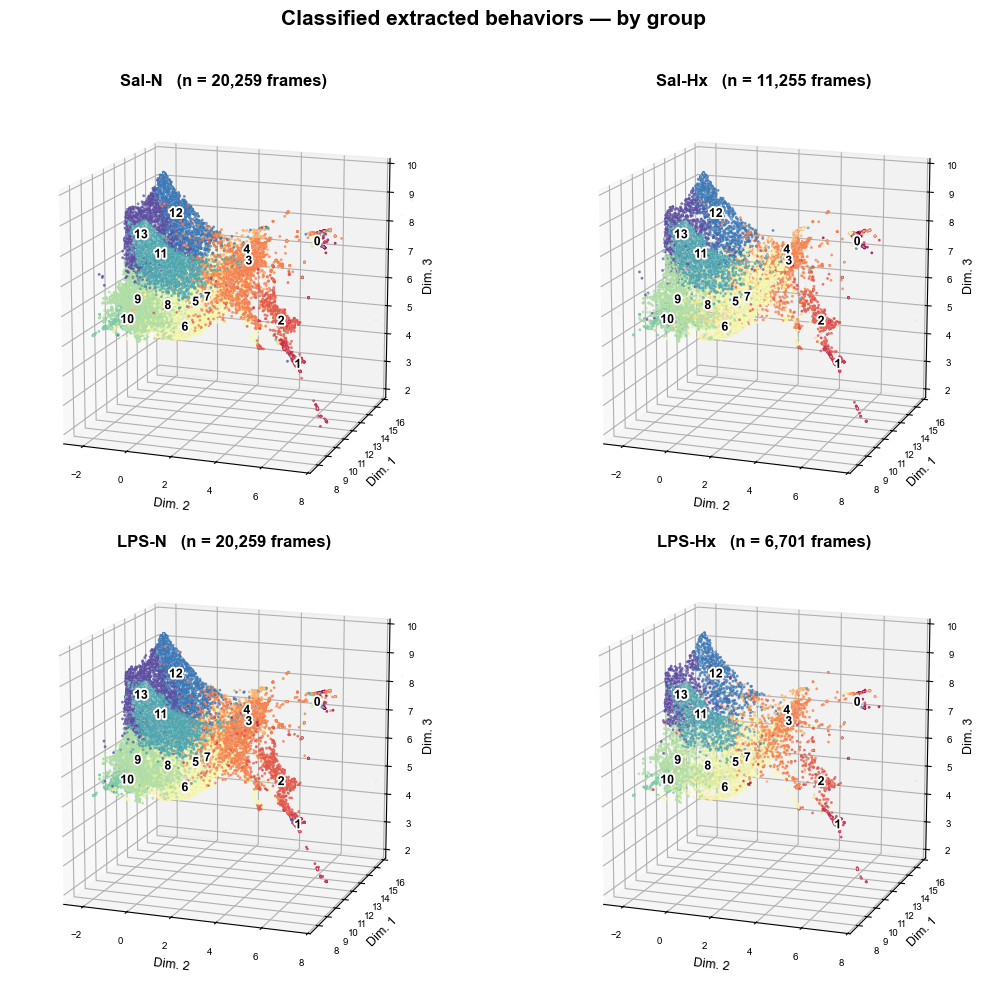

In [3]:
# ---- Per-group 2x2 panel of the same 3D embedding ----
# Published-style polish, mirroring Fig 7E (i):
#   * uniform alpha and point size across all 14 clusters
#   * cube box aspect (1, 1, 1)
#   * only clusters 1 and 8 carry centroid labels (boxed)
#   * same view angle (elev=30, azim=-70) so the four panels read against
#     Fig 7E (i) directly
#   * a thin grey "where the cloud sits" silhouette underneath, so empty
#     regions of behaviour-space stay visible as context even when this
#     group has no points there

GROUP_ORDER = ["Sal-N", "Sal-Hx", "LPS-N", "LPS-Hx"]

assert "group" in df.columns, (
    "fig7E_umap3d.csv is missing the 'group' column — re-run the precompute "
    "step that maps each B-SOiD frame to its experimental group."
)

# Print group counts so the reader sees the per-panel sample size.
print(df.groupby("group").size().rename("frames").to_frame().T[GROUP_ORDER])

fig = plt.figure(figsize=(11.5, 10), facecolor="white")
fig.suptitle("Classified extracted behaviors — by group",
             fontsize=15, fontweight="bold", y=0.985)

# Same axis limits as Fig 7E (i)
xlim2 = core_range(df["x"])
ylim2 = core_range(df["y"])
zlim2 = core_range(df["z"])

# Pre-sample a single global silhouette so all four panels share it.
bg = df.sample(min(3000, len(df)), random_state=42)

for i, grp in enumerate(GROUP_ORDER):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d", facecolor="white")
    sub = df[df["group"] == grp]

    # Silhouette of the full cloud — context for empty regions.
    ax.scatter(bg["x"], bg["y"], bg["z"],
               s=1.0, c="#dddddd", alpha=0.30,
               linewidths=0, depthshade=True, zorder=1)

    # This group's points, B-SOiD palette, uniform alpha + size (matches
    # Fig 7E (i) so panels can be compared at a glance).
    sizes_g = sub["cluster"].value_counts()
    order_g = list(sizes_g.sort_values(ascending=False).index)
    for c in order_g:
        pts  = sub[sub["cluster"] == c]
        keep = (pts["x"].between(*xlim2) &
                pts["y"].between(*ylim2) &
                pts["z"].between(*zlim2))
        pts = pts[keep]
        ax.scatter(pts["x"], pts["y"], pts["z"],
                   c=[PALETTE[c]], s=4.0, marker="o", alpha=0.80,
                   linewidths=0, depthshade=True, zorder=3)

    # Centroid labels for all 14 clusters — transparent background,
    # thick white halo. Same global centroid across panels.
    for c in range(n_clusters):
        pts = df[df["cluster"] == c]
        cx, cy, cz = pts["x"].median(), pts["y"].median(), pts["z"].median()
        ax.text(cx, cy, cz, str(c),
                color="black", fontsize=9, fontweight="bold",
                ha="center", va="center", zorder=20,
                path_effects=[withStroke(linewidth=2.8, foreground="white")])

    ax.set_xlim(*xlim2); ax.set_ylim(*ylim2); ax.set_zlim(*zlim2)
    ax.set_box_aspect((1, 1, 1))           # cube aspect, matching Fig 7E (i)

    ax.set_xlabel("Dim. 2", labelpad=1, fontsize=9)
    ax.set_ylabel("Dim. 1", labelpad=1, fontsize=9)
    ax.set_zlabel("Dim. 3", labelpad=1, fontsize=9)
    ax.tick_params(axis="both", which="major", labelsize=7)
    ax.grid(True, linewidth=0.3, color="#dddddd", alpha=0.5)
    ax.set_title(f"{grp}   (n = {len(sub):,} frames)",
                 fontsize=12, fontweight="bold", pad=4)
    ax.view_init(elev=15, azim=-70)        # match Fig 7E (i)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("Fig7E_per_group.pdf", bbox_inches="tight")
fig.savefig("Fig7E_per_group.png", dpi=300, bbox_inches="tight")
plt.show()


## Fig 7E (iii) — Annotated 2D UMAP map (alternative variant)

An alternative to the 3D scatter: a clean 2D UMAP view with each of the
14 B-SOiD clusters drawn as a solid-coloured blob and labelled in a
rounded coloured box around the perimeter of the figure. Dashed leader
lines connect each label back to its cluster centroid, mirroring the
annotation style of common behaviour-clustering schematics.

**Coordinates.** Built from the same canonical B-SOiD 3D UMAP coords
(`x`, `y`, `z` = Dim 2 / Dim 1 / Dim 3 in the column rename done above).
We project onto **Dim 1 × Dim 2** (`y` vs `x`), which preserves the
cluster separation of the 3D view in a flat layout.


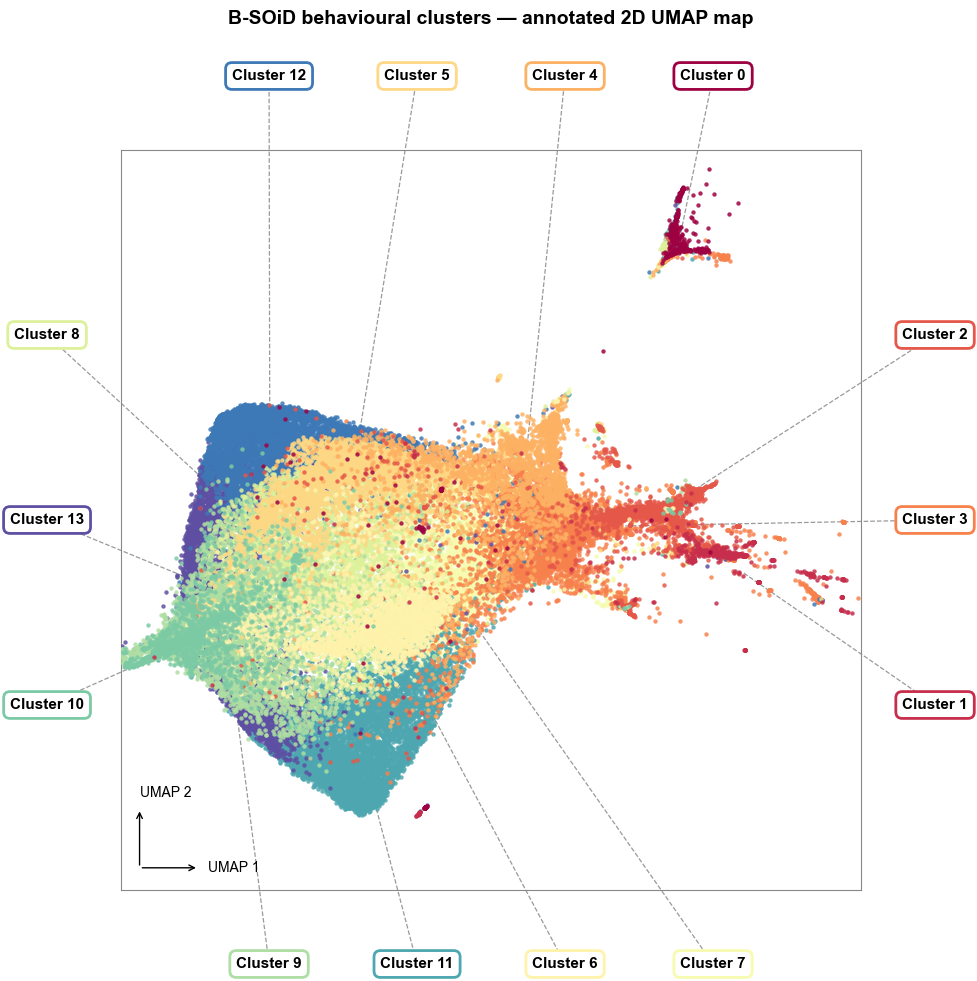

In [4]:
# ---- Fig 7E (iii) — Annotated 2D UMAP map ----
# Rectangular-perimeter layout mirroring the published-style figure: cluster
# labels arranged around all four edges of the figure (4 top / 4 bottom / 3
# left / 3 right = 14 slots) so the perimeter is used efficiently and
# leader lines stay strictly radial, no crossings.

# ---- 2D projection ----
U_X = df["x"]      # horizontal axis = Dim 2
U_Y = df["y"]      # vertical   axis = Dim 1

data_x_lo, data_x_hi = U_X.quantile(0.005), U_X.quantile(0.995)
data_y_lo, data_y_hi = U_Y.quantile(0.005), U_Y.quantile(0.995)
data_cx   = 0.5 * (data_x_lo + data_x_hi)
data_cy   = 0.5 * (data_y_lo + data_y_hi)
data_half = 0.5 * max(data_x_hi - data_x_lo, data_y_hi - data_y_lo)
# Frame hugs the data; labels live OUTSIDE the frame.
frame_half = data_half * 1.05
ux_lo, ux_hi = data_cx - frame_half, data_cx + frame_half
uy_lo, uy_hi = data_cy - frame_half, data_cy + frame_half

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")

# ---- Scatter ----
sizes_iii      = df["cluster"].value_counts()
plot_order_iii = list(sizes_iii.sort_values(ascending=False).index)
for c in plot_order_iii:
    pts  = df[df["cluster"] == c]
    keep = (pts["x"].between(ux_lo, ux_hi) & pts["y"].between(uy_lo, uy_hi))
    pts  = pts[keep]
    ax.scatter(pts["x"], pts["y"],
               c=[PALETTE[c]], s=10, alpha=0.85,
               linewidths=0, zorder=3)

# ---- Cluster centroids in 2D ----
cents = {c: (df.loc[df["cluster"]==c, "x"].median(),
             df.loc[df["cluster"]==c, "y"].median())
         for c in range(n_clusters)}

# ---- Build 14 rectangular-perimeter slots (CCW from lower-right) ----
def make_perimeter_slots(x_min, x_max, y_min, y_max,
                         n_right=3, n_top=4, n_left=3, n_bottom=4,
                         inset_frac=0.04):
    """Returns slots in counter-clockwise order starting from lower-right."""
    slots = []
    # Right edge, bottom-to-top
    for i in range(n_right):
        frac = (i + 1) / (n_right + 1)
        slots.append((x_max + inset_frac * (x_max - x_min),
                      y_min + frac * (y_max - y_min)))
    # Top edge, right-to-left
    for i in range(n_top):
        frac = (i + 1) / (n_top + 1)
        slots.append((x_max - frac * (x_max - x_min),
                      y_max + inset_frac * (y_max - y_min)))
    # Left edge, top-to-bottom
    for i in range(n_left):
        frac = (i + 1) / (n_left + 1)
        slots.append((x_min - inset_frac * (x_max - x_min),
                      y_max - frac * (y_max - y_min)))
    # Bottom edge, left-to-right
    for i in range(n_bottom):
        frac = (i + 1) / (n_bottom + 1)
        slots.append((x_min + frac * (x_max - x_min),
                      y_min - inset_frac * (y_max - y_min)))
    return slots

# Slots sit OUTSIDE the data frame. `outset_frac` is a fraction
# of the frame half-width; bigger -> further out from the frame.
outset_frac = 0.10
slot_xy = make_perimeter_slots(ux_lo, ux_hi, uy_lo, uy_hi,
                               inset_frac=outset_frac)
assert len(slot_xy) == n_clusters

# ---- Figure-center reference (centroid of cluster centroids) ----
cx0 = float(np.mean([p[0] for p in cents.values()]))
cy0 = float(np.mean([p[1] for p in cents.values()]))

def ccw_angle(p):
    """Angle from figure centre, in [0, 2*pi)."""
    a = np.arctan2(p[1] - cy0, p[0] - cx0)
    return a + 2 * np.pi if a < 0 else a

# ---- Non-crossing assignment ----
# Sort clusters CCW by centroid angle; sort slots CCW by slot angle (already
# in CCW order from make_perimeter_slots, but recompute by angle for safety).
clusters_ccw = sorted(range(n_clusters), key=lambda c: ccw_angle(cents[c]))
slots_ccw    = sorted(range(len(slot_xy)), key=lambda s: ccw_angle(slot_xy[s]))

# Try all 14 cyclic offsets of slots -> clusters, pick the one with smallest
# total angular mismatch. This is the rotation that best aligns slot order
# with centroid order while preserving non-crossing.
best_offset = 0
best_score  = float("inf")
for off in range(n_clusters):
    score = 0.0
    for i, c in enumerate(clusters_ccw):
        s = slots_ccw[(i + off) % n_clusters]
        ccx, ccy = cents[c]
        ssx, ssy = slot_xy[s]
        # Squared Euclidean leader length -> rotation that puts
        # extreme clusters (e.g. 0 in the upper-right corner)
        # in the slot physically closest to them.
        score += (ccx - ssx)**2 + (ccy - ssy)**2
    if score < best_score:
        best_score  = score
        best_offset = off

assignment = {}                              # cluster_id -> slot_index
for i, c in enumerate(clusters_ccw):
    assignment[c] = slots_ccw[(i + best_offset) % n_clusters]

# Manual swaps for visual clarity (adjacent perimeter slots only,
# never introduces crossings because the swapped slots are
# neighbours in the CCW order).
MANUAL_SWAPS = [(0, 4), (11, 6)]
for a, b in MANUAL_SWAPS:
    if a in assignment and b in assignment:
        assignment[a], assignment[b] = assignment[b], assignment[a]

# ---- Draw leader lines + boxed labels ----
for c in range(n_clusters):
    cxc, cyc = cents[c]
    lxc, lyc = slot_xy[assignment[c]]
    rgba     = PALETTE[c]
    ax.plot([cxc, lxc], [cyc, lyc],
            color="#888888", linestyle="--", linewidth=0.9,
            zorder=2, alpha=0.85, clip_on=False)
    ax.text(lxc, lyc, f"Cluster {c}",
            color="black", fontsize=11, fontweight="bold",
            ha="center", va="center", zorder=12,
            clip_on=False,
            bbox=dict(boxstyle="round,pad=0.42",
                      facecolor="white",
                      edgecolor=rgba, linewidth=2.0))

# ---- Framed axes (thin grey box around the whole panel) ----
ax.set_xlim(ux_lo, ux_hi)
ax.set_ylim(uy_lo, uy_hi)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('#888888')
    s.set_linewidth(0.8)
ax.set_aspect('equal')   # square data units -> cloud sits
                          # centred inside the square frame

# ---- Corner UMAP-1 / UMAP-2 arrow indicator ----
arr_x = ux_lo + 0.025 * (ux_hi - ux_lo)
arr_y = uy_lo + 0.030 * (uy_hi - uy_lo)
arr_len_x = 0.08 * (ux_hi - ux_lo)
arr_len_y = 0.08 * (uy_hi - uy_lo)
ax.annotate("", xy=(arr_x + arr_len_x, arr_y), xytext=(arr_x, arr_y),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0))
ax.annotate("", xy=(arr_x, arr_y + arr_len_y), xytext=(arr_x, arr_y),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0))
ax.text(arr_x + arr_len_x + 0.012 * (ux_hi - ux_lo), arr_y,
        "UMAP 1", fontsize=10, va="center", ha="left")
ax.text(arr_x, arr_y + arr_len_y + 0.012 * (uy_hi - uy_lo),
        "UMAP 2", fontsize=10, va="bottom", ha="left")

fig.suptitle("B-SOiD behavioural clusters — annotated 2D UMAP map",
             fontsize=14, fontweight="bold", y=0.96)

plt.subplots_adjust(left=0.08, right=0.92, top=0.82, bottom=0.08)
fig.savefig("Fig7E_annotated2D.pdf", bbox_inches="tight")
fig.savefig("Fig7E_annotated2D.png", dpi=300, bbox_inches="tight")
plt.show()


## Fig 7E (iv) — Clean 3D variant (no labels, white panes, minimal grid)

Same canonical B-SOiD 3D UMAP coordinates and palette as Fig 7E (i), but
stripped of every annotation: no cluster-number labels, no boxed
highlights, no axis ticks. The three pane backgrounds are forced to
white and the gridlines are reduced to the faintest visible line so the
scatter cloud reads against an almost-blank backdrop while still
preserving a sense of 3D depth via the back wall, side wall and floor
edges.


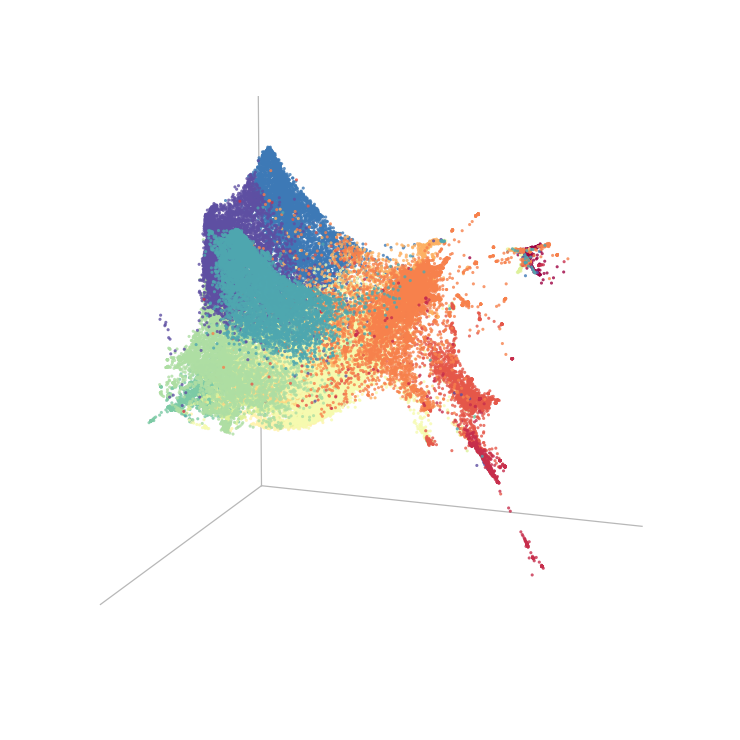

In [5]:
# ---- Fig 7E (iv) — Clean 3D variant ----
# Same coords/palette/axis-permutation as Fig 7E (i), but stripped of
# every annotation: no cluster labels, no axis ticks, no axis text, no
# legend, no title. No enclosing cube — only the three cube edges at the
# far (back) corner render, as a faint open frame behind the cloud.

fig = plt.figure(figsize=(8.5, 7.5), facecolor="white")
ax  = fig.add_subplot(111, projection="3d", facecolor="white")

# ---- Scatter ----
sizes_iv      = df["cluster"].value_counts()
plot_order_iv = list(sizes_iv.sort_values(ascending=False).index)
for c in plot_order_iv:
    pts  = df[df["cluster"] == c]
    keep = (pts["x"].between(*xlim) &
            pts["y"].between(*ylim) &
            pts["z"].between(*zlim))
    pts  = pts[keep]
    ax.scatter(pts["x"], pts["y"], pts["z"],
               c=[PALETTE[c]], label=int(c),
               s=5.0, marker="o", alpha=0.80,
               linewidths=0, depthshade=True)

# ---- Force panes white and hide every default axis line ----
WHITE_RGBA = (1.0, 1.0, 1.0, 1.0)
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.set_facecolor(WHITE_RGBA)
    pane.set_edgecolor((0, 0, 0, 0))      # no back-wall rectangles

# Kill the default axis lines, ticks, and any internal "axisline" so
# the only cube outline visible is the one we draw manually.
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis._axinfo["axisline"]["color"]      = (1, 1, 1, 0)
    axis._axinfo["axisline"]["linewidth"]  = 0
    axis._axinfo["tick"]["inward_factor"]  = 0
    axis._axinfo["tick"]["outward_factor"] = 0
    axis.line.set_color((1, 1, 1, 0))
    axis.line.set_linewidth(0)

# Minimal grid (hairline) for depth cueing.
ax.grid(True)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis._axinfo["grid"]["color"]     = (0.88, 0.88, 0.88, 1.0)
    axis._axinfo["grid"]["linestyle"] = "-"
    axis._axinfo["grid"]["linewidth"] = 0.25

# No axis labels, no tick numbers.
ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.set_box_aspect((1, 1, 1))
ax.set_axis_off()   # remove ALL default 3D chrome (panes/box/grid/ticks);
                    # the only lines drawn are the back-corner edges below

# ---- Only the lines at the back: 3 edges at the far corner ----
# Outer box removed. Draw just the three cube edges incident to the corner
# farthest from the camera, so a faint open frame sits behind the cloud.
def _draw_back_corner(ax, xlim, ylim, zlim, elev, azim,
                      color=(0.72, 0.72, 0.72, 1.0), lw=0.9):
    e, a = np.radians(elev), np.radians(azim)
    cam = (np.cos(e) * np.cos(a), np.cos(e) * np.sin(a), np.sin(e))
    x0, x1 = xlim; y0, y1 = ylim; z0, z1 = zlim
    cx, ox = (x0, x1) if cam[0] > 0 else (x1, x0)
    cy, oy = (y0, y1) if cam[1] > 0 else (y1, y0)
    cz, oz = (z0, z1) if cam[2] > 0 else (z1, z0)
    ax.plot([cx, ox], [cy, cy], [cz, cz], color=color, lw=lw, zorder=0.5)
    ax.plot([cx, cx], [cy, oy], [cz, cz], color=color, lw=lw, zorder=0.5)
    ax.plot([cx, cx], [cy, cy], [cz, oz], color=color, lw=lw, zorder=0.5)

_draw_back_corner(ax, xlim, ylim, zlim, elev=15, azim=-70)

# Clean base for the composite: no legend, no title — cluster labels and
# mouse illustrations are overlaid downstream in the design tool.
ax.view_init(elev=15, azim=-70)

plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)
fig.savefig("Fig7E.pdf", bbox_inches="tight")
fig.savefig("Fig7E.png", dpi=300, bbox_inches="tight")
plt.show()
